<a href="https://colab.research.google.com/github/sierramendoza543/sierra-gating-project/blob/main/edits_syntheticdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Environment:** despite the Colab badge (kept for convenience), this notebook has no actual Colab dependency -- it runs the same in a local Jupyter/venv (numpy, pandas, scipy, matplotlib, seaborn, scikit-learn). Everything needed to reproduce a run is the fixed `seed` in Step 1 plus the parameters in Step 2 -- no external data files are read.

**Step 1: imports and random seed.** Fixes reproducibility for everything that follows. This uses the legacy global `np.random` state; a few later steps (the copula draws in Step 8, the subtype assignment in Step 3) deliberately use separate `np.random.default_rng(seed)` instances instead, so they don't shift the legacy stream's sequence and disturb draws elsewhere. Cells must be run top-to-bottom once at the start of a session -- re-running an individual cell out of order will re-consume random draws and desynchronize downstream results from what's shown here.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

#testedit

seed = 42
np.random.seed(seed)

print("Imported numpy, pandas, scipy.stats, matplotlib, seaborn")
print("Random seed set to", seed)

Imported numpy, pandas, scipy.stats, matplotlib, seaborn
Random seed set to 42


**Step 2: all simulation parameters, in one place.** Cohort size, expression parameters, gene-module design, disease-subtype design, and the numerical-robustness constants used later are all defined here. Change values here rather than inline further down in the notebook.

In [2]:
# Step 2: harder simulation parameters
#
n_patients_group1 = 10
n_patients_group2 = 10
cells_per_patient = 50
n_genes_total = 1000
n_signal_genes = 100

fold_change = 3
mu_background = 2
sigma2 = 0.20
dispersion = 15.0

size_factor_mean = 2000
size_factor_sd = 300

# --- correlated gene module parameters ---
# Split the 100 signal genes into equal-size modules. All but the last
# module are "disease modules" (their mean expression differs by group,
# same as before). The last module is a "distractor": genes inside it are
# just as correlated with each other as a disease module, but its mean does
# NOT differ between groups — a negative control to check that L1 (and later
# the group-aware method) isn't fooled into selecting a module just because
# it's correlated.
n_modules = 4
n_distractor_modules = 1
genes_per_module = n_signal_genes // n_modules
within_module_correlation = 0.6  # target Pearson rho between genes in the same module

# How "clean" the module correlation looks: 0.0 = every gene pair inside a
# module has EXACTLY within_module_correlation (a perfectly uniform block on
# the heatmap). Raising this jitters each pair's correlation around that
# target instead (a messier, more realistic-looking block), at the cost of
# pulling the realized average correlation down a bit once the matrix is
# repaired back into a valid correlation matrix (see build_module_corr_matrix
# in Step 8). Try ~0.05-0.15 for "a bit noisy", ~0.2-0.3 for "quite noisy".
# 0.0 reproduces the original perfect-block behavior exactly.
correlation_noise = 0.0

# --- disease subtype (heterogeneity) parameters ---
# Real diseases like IPF/COPD/FHP usually aren't one uniform biological
# process -- different patients sharing the same diagnosis can be driven by
# different (overlapping) gene programs. To simulate that, each Group1
# (diseased) patient is secretly assigned one of a few subtypes, and only
# the modules THAT subtype activates get boosted for that patient -- other
# disease modules sit at baseline for them, same as if they were healthy.
# Group2 (healthy) patients are unaffected and stay homogeneous.
#
# No method being tested ever sees `subtype` -- it's ground truth for
# grading a future clustering/subtype-discovery step, not a model input.
#
# subtype_module_indices: which disease-module INDICES (into the eventual
# `disease_modules` list, resolved in Step 5) each subtype activates.
# Overlap is deliberate -- e.g. S1 and S2 both touch module index 1 -- real
# molecular subtypes typically share some pathways and differ in others,
# not a clean partition.
n_subtypes = 3
subtype_names = [f"S{i+1}" for i in range(n_subtypes)]
subtype_module_indices = {
    "S1": [0, 1],  # first two disease modules
    "S2": [1, 2],  # second and third disease modules (overlaps S1 on index 1)
    "S3": [0],     # first disease module only (overlaps S1 on index 0)
}

# --- numerical / robustness constants ---
# Named here (rather than left as inline literals) so their rationale is
# documented once and any future tuning happens in one place.
MU_FLOOR = 1e-6
# Floors a Negative-Binomial mean just above zero. The additive gamma_i term
# (Step 8) has no built-in guarantee of staying positive for an extreme
# draw, and mu<=0 makes the NB var/p/n algebra undefined. 1e-6 is small
# enough to never visibly distort real (positive) means, but large enough
# to keep every downstream ratio well-defined. Under the current sigma2 this
# floor never actually triggers (checked: gamma_i would need to be >4 std
# devs out) -- it exists to protect future sigma2 sweeps (methodology step 5).

EIGENVALUE_FLOOR = 1e-6
# Used in build_module_corr_matrix (Step 8) when correlation_noise > 0: after
# jittering the compound-symmetric correlation matrix, any eigenvalue below
# this is clipped up to it before rescaling back to a unit-diagonal
# correlation matrix. This is a SINGLE-PASS repair, not an iterative
# algorithm -- for the jitter magnitudes this notebook uses (correlation_noise
# up to ~0.5, see Step 2 sweep results), one clip-and-rescale pass reliably
# yields a valid, Cholesky-decomposable matrix. A true nearest-correlation-
# matrix algorithm (e.g. Higham 2002) would iterate to convergence instead;
# that wasn't needed here but would be the next step if correlation_noise
# were pushed much higher.

CHOLESKY_JITTER = 1e-8  # tiny diagonal nudge for numerical stability right before np.linalg.cholesky

U_CLIP_EPS = 1e-6
# The copula maps each gene's latent normal to a uniform via the normal CDF,
# then inverts the gene's own NB CDF at that uniform. Uniforms of exactly 0
# or 1 invert to -inf/+inf under nbinom.ppf, so they're clipped to
# [U_CLIP_EPS, 1 - U_CLIP_EPS] first.

# --- L1 baseline hyperparameters ---
L1_TEST_SIZE = 0.2       # GroupShuffleSplit fraction held out for test, split by patient
L1_C = 0.0068            # L1 inverse regularization strength; retuned whenever module/subtype params change (see Step 12 sweep notes)
L1_MAX_ITER = 5000

PCA_N_COMPONENTS = 2     # Step 11h

# --- output paths (no file I/O is active by default; these just name the
# targets for the commented-out export cell at the very end, so uncommenting
# it doesn't require re-inventing filenames) ---
OUTPUT_DIR = "."
COUNTS_CSV = "counts_long.csv"
EXPRESSION_MATRIX_CSV = "expression_matrix.csv"
GENES_CSV = "genes_labels.csv"
PATIENTS_CSV = "patients.csv"

print("Simulation parameters defined")
print("Group 1 patients:", n_patients_group1)
print("Group 2 patients:", n_patients_group2)
print("Cells per patient:", cells_per_patient)
print("Total genes:", n_genes_total)
print("Signal genes:", n_signal_genes)
print("Fold change:", fold_change)
print("Modules:", n_modules, "x", genes_per_module, "genes (", n_distractor_modules, "distractor )")
print("Within-module target correlation:", within_module_correlation)
print("Correlation noise:", correlation_noise)
print("Subtypes:", subtype_names, "-> module indices", subtype_module_indices)

Simulation parameters defined
Group 1 patients: 10
Group 2 patients: 10
Cells per patient: 50
Total genes: 1000
Signal genes: 100
Fold change: 3
Modules: 4 x 25 genes ( 1 distractor )
Within-module target correlation: 0.6
Correlation noise: 0.0
Subtypes: ['S1', 'S2', 'S3'] -> module indices {'S1': [0, 1], 'S2': [1, 2], 'S3': [0]}


**Step 3: patient-level metadata.** Assigns each patient to Group1 (diseased) or Group2 (healthy), and assigns each Group1 patient a hidden disease **subtype** (new) used only to decide which gene modules get boosted for them in Step 8. No downstream feature-selection method ever sees `subtype` directly -- it exists purely as ground truth for evaluating a future clustering/subtype-discovery step, the same way `module_id` (Step 5) is ground truth for evaluating gene-level feature recovery.

In [3]:
# Step 3: create patient metadata
#
# Each Group1 (diseased) patient also gets a hidden `subtype` label. This is
# ground truth only -- no classifier or feature-selection method below ever
# sees this column. It exists so a later clustering/contrastive-learning
# step can be graded against the true subtype structure, the same way
# `module_id` (Step 5) lets us grade gene-level feature recovery.
#
# A separate Generator is used for the subtype draw so it doesn't disturb
# the legacy global np.random sequence that size_factor/gamma_i depend on.

patient_ids = [f"P{i+1}" for i in range(n_patients_group1 + n_patients_group2)]
groups = (
    ["Group1"] * n_patients_group1 +
    ["Group2"] * n_patients_group2
)

rng_subtype = np.random.default_rng(seed)
subtypes = (
    list(rng_subtype.choice(subtype_names, size=n_patients_group1)) +
    ["none"] * n_patients_group2  # Group2 stays homogeneous -- no subtype structure
)

patients_df = pd.DataFrame({
    "patient_id": patient_ids,
    "group": groups,
    "subtype": subtypes
})

print("Group1 subtype counts:")
print(patients_df.loc[patients_df["group"] == "Group1", "subtype"].value_counts())
patients_df

Group1 subtype counts:
subtype
S1    4
S3    3
S2    3
Name: count, dtype: int64


,patient_id,group,subtype
0,P1,Group1,S1
1,P2,Group1,S3
2,P3,Group1,S2
3,P4,Group1,S2
4,P5,Group1,S2
5,P6,Group1,S3
6,P7,Group1,S1
7,P8,Group1,S3
8,P9,Group1,S1
9,P10,Group1,S1


**Step 4: cell-level metadata.** Each patient contributes multiple cells, and each cell gets its own `size_factor` -- a technical sequencing-depth effect, not biology. This is the quantity that later needs to be normalized out (Step 11b onward) before measuring "real" gene-gene correlation.

In [4]:
# Step 4: create cell metadata with size factors

cell_rows = []

for _, row in patients_df.iterrows():
    patient_id = row["patient_id"]
    group = row["group"]

    size_factors = np.random.normal(loc=size_factor_mean, scale=size_factor_sd, size=cells_per_patient)
    size_factors = np.clip(size_factors, a_min=1, a_max=None)

    for cell_idx in range(cells_per_patient):
        cell_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": f"{patient_id}_C{cell_idx+1}",
            "size_factor": size_factors[cell_idx]
        })

cells_df = pd.DataFrame(cell_rows)

cells_df.head()

,patient_id,group,cell_id,size_factor
0,P1,Group1,P1_C1,2149.014246
1,P1,Group1,P1_C2,1958.520710
2,P1,Group1,P1_C3,2194.306561
3,P1,Group1,P1_C4,2456.908957
4,P1,Group1,P1_C5,1929.753988


**Step 5: gene labeling and module assignment.** Splits the 100 "signal" genes into 4 correlated modules (3 disease modules + 1 distractor negative control), and resolves the subtype-to-module activation map defined in Step 2 (module *indices*) into actual module *names*, now that `disease_modules` exists.

In [5]:
# Step 5: label genes and assign correlated gene modules

gene_ids = [f"G{i+1}" for i in range(n_genes_total)]

signal_gene_ids = gene_ids[:n_signal_genes]
background_gene_ids = gene_ids[n_signal_genes:]

module_names = [f"M{i+1}" for i in range(n_modules)]
disease_modules = module_names[: n_modules - n_distractor_modules]
distractor_module_names = module_names[n_modules - n_distractor_modules :]

gene_module = {}
for m_idx, module in enumerate(module_names):
    start = m_idx * genes_per_module
    end = start + genes_per_module
    for gene_id in signal_gene_ids[start:end]:
        gene_module[gene_id] = module

genes_df = pd.DataFrame({
    "gene_id": gene_ids,
    "gene_type": ["signal"] * n_signal_genes + ["background"] * (n_genes_total - n_signal_genes)
})
genes_df["module_id"] = genes_df["gene_id"].map(gene_module).fillna("none")
genes_df["is_disease_module"] = genes_df["module_id"].isin(disease_modules)

# Resolve Step 2's subtype_module_indices (module INDICES) into actual
# module NAMES now that disease_modules exists -- e.g. {"S1": [0, 1]} ->
# {"S1": {"M1", "M2"}}. Kept as a set per subtype since membership (not
# order) is all that matters when Step 8 checks "is this module active for
# this patient's subtype".
subtype_module_map = {
    subtype: {disease_modules[i] for i in indices}
    for subtype, indices in subtype_module_indices.items()
}

print("Disease modules (mean differs by group):", disease_modules)
print("Distractor modules (correlated, but NOT group-differential):", distractor_module_names)
print("Subtype -> active (boosted) disease modules:")
for subtype in subtype_names:
    print(f"  {subtype}: {sorted(subtype_module_map[subtype])}")
genes_df.head(10)

Disease modules (mean differs by group): ['M1', 'M2', 'M3']
Distractor modules (correlated, but NOT group-differential): ['M4']
Subtype -> active (boosted) disease modules:
  S1: ['M1', 'M2']
  S2: ['M2', 'M3']
  S3: ['M1']


,gene_id,gene_type,module_id,is_disease_module
0,G1,signal,M1,True
1,G2,signal,M1,True
2,G3,signal,M1,True
3,G4,signal,M1,True
4,G5,signal,M1,True
5,G6,signal,M1,True
6,G7,signal,M1,True
7,G8,signal,M1,True
8,G9,signal,M1,True
9,G10,signal,M1,True


**Step 6: patient random effects (`gamma_i`).** A per-patient intercept representing a genuine patient-level effect (e.g. overall transcriptional activity or technical batch). Step 8 applies it additively to disease, distractor, and background genes alike -- see the "patient-effect floor" note there for why that matters.

In [6]:
# Step 6: patient random effects

patient_effects = np.random.normal(
    loc=0,
    scale=np.sqrt(sigma2),
    size=len(patients_df)
)

patients_df["gamma_i"] = patient_effects

patients_df

,patient_id,group,subtype,gamma_i
0,P1,Group1,S1,0.625811
1,P2,Group1,S3,0.413509
2,P3,Group1,S2,0.026668
3,P4,Group1,S2,-0.289319
4,P5,Group1,S2,0.312255
5,P6,Group1,S3,0.175972
6,P7,Group1,S1,0.400343
7,P8,Group1,S3,0.284057
8,P9,Group1,S1,0.469374
9,P10,Group1,S1,-0.239364


**Step 7: baseline group-level means.** Defines the "boosted" mean used for a disease module when a patient's subtype activates it (`mu_group1_signal`), vs. the baseline mean used everywhere else (`mu_background`). The actual per-patient, per-module decision of *which* mean applies happens in Step 8, gated by subtype.

In [7]:
# Step 7: define group-specific means
#
# Disease-module genes: mean shifts with group (fold_change applied in Group1)
# Distractor-module genes: same mean in both groups (correlated, not diagnostic)
# Background genes: unchanged, independent, same mean in both groups

mu_group1_signal = mu_background * fold_change
mu_group2_signal = mu_background

mu_group1_background = mu_background
mu_group2_background = mu_background

print("mu_group1_signal (disease modules, Group1) =", mu_group1_signal)
print("mu_group2_signal (disease modules, Group2) =", mu_group2_signal)
print("mu_group1_background (distractor module + background, Group1) =", mu_group1_background)
print("mu_group2_background (distractor module + background, Group2) =", mu_group2_background)

mu_group1_signal (disease modules, Group1) = 6
mu_group2_signal (disease modules, Group2) = 2
mu_group1_background (distractor module + background, Group1) = 2
mu_group2_background (distractor module + background, Group2) = 2


**Step 8: the core generative step.** Simulates every gene's expression count via a module-aware Gaussian copula NB model. This is where group, subtype, module membership, patient effect, and technical size factor all combine into a single mean per (patient, cell, gene) -- the most important cell in the notebook to understand.

In [8]:
# Step 8: simulate gene expression counts (module-aware Gaussian copula NB sampling)
#
# Genes within the same module are sampled with a Gaussian copula: draw a
# vector of correlated standard-normal latents per (module, cell) using a
# module correlation matrix (see build_module_corr_matrix below -- rho on
# the off-diagonals, optionally jittered by correlation_noise), map each
# latent to a uniform via the standard normal CDF, then invert each gene's
# own NB CDF at that uniform (nbinom.ppf). This keeps every gene's marginal
# NB distribution exactly as parameterized (same mean/dispersion as before)
# while inducing real pairwise correlation among genes in the same module.
# Background genes are sampled independently, unchanged.
#
# gamma_i (the patient random effect) is applied additively to every gene's
# mean -- disease-module, distractor-module, and background alike -- since
# it represents a patient-level effect (e.g. overall transcriptional
# activity/technical variation) that should shift all of that patient's
# expression together, not just the disease-relevant genes.
#
# Disease-module boosting is now gated by subtype: a disease module's mean
# only gets the fold_change boost for a Group1 patient if subtype_module_map
# says that patient's subtype activates it. A disease module the patient's
# subtype does NOT activate sits at the same baseline as the distractor
# module and background -- exactly as if that patient were healthy for that
# specific module. Group2 patients never get any module boosted.
#
# mu is floored at MU_FLOOR (Step 2) since the additive gamma_i term has no
# built-in positivity guarantee; mu_floor_trigger_count below records how
# often that actually mattered, so the assertion after the loop is checking
# a real measurement, not just hoping.
#
# A separate Generator is used for the copula draws so the existing global
# np.random stream (patients_df, cells_df, background genes) is undisturbed.

from scipy.stats import nbinom, norm

rng = np.random.default_rng(seed)

def build_module_corr_matrix(size, rho, noise, rng):
    """Compound-symmetric correlation matrix (rho off-diagonal). If noise > 0,
    jitter each pair's correlation with Gaussian noise, then repair the
    result back into a valid correlation matrix (clip negative eigenvalues,
    rescale to a unit diagonal) -- this is what makes the module's heatmap
    block look "noisy"/imperfect instead of a flat, uniform rho everywhere.
    noise=0 reproduces the exact uniform-rho matrix used previously.

    This is a SINGLE-PASS repair, not an iterative nearest-correlation-matrix
    algorithm: one jitter -> eigenvalue-clip -> rescale pass. That's been
    sufficient for every correlation_noise value tested here (0 to 0.5 --
    see Step 2); a true iterative algorithm (e.g. Higham 2002) would only be
    needed if noise were pushed high enough that one pass stopped producing
    a valid matrix, which the assertions right after this call would catch."""
    corr = np.eye(size) * (1 - rho) + rho
    if noise > 0:
        jitter = rng.normal(loc=0.0, scale=noise, size=(size, size))
        jitter = (jitter + jitter.T) / 2
        np.fill_diagonal(jitter, 0.0)
        corr = corr + jitter
        eigvals, eigvecs = np.linalg.eigh(corr)
        eigvals = np.clip(eigvals, EIGENVALUE_FLOOR, None)
        corr = eigvecs @ np.diag(eigvals) @ eigvecs.T
        d = np.sqrt(np.diag(corr))
        corr = corr / np.outer(d, d)
    corr += np.eye(size) * CHOLESKY_JITTER  # numerical safety margin before Cholesky
    return corr

# One correlation matrix / Cholesky factor covers every module (same size,
# same target rho + noise), so compute it once.
corr_matrix = build_module_corr_matrix(genes_per_module, within_module_correlation, correlation_noise, rng)

# Assert the repaired matrix is actually a valid correlation matrix before
# trusting Cholesky on it -- catches a broken build_module_corr_matrix call
# (e.g. correlation_noise pushed too high for a single-pass repair) here,
# at the source, instead of as a confusing nbinom error deep in the loop below.
assert np.allclose(corr_matrix, corr_matrix.T, atol=1e-6), "module correlation matrix must be symmetric"
assert np.allclose(np.diag(corr_matrix), 1.0, atol=1e-4), "module correlation matrix must have a unit diagonal"
assert np.all(np.linalg.eigvalsh(corr_matrix) > 0), "module correlation matrix must be positive definite for Cholesky"

chol_factor = np.linalg.cholesky(corr_matrix)

module_gene_lists = {
    module: genes_df.loc[genes_df["module_id"] == module, "gene_id"].tolist()
    for module in module_names
}

count_rows = []
mu_floor_trigger_count = 0  # how many times the raw (pre-floor) mu was <= 0

for _, cell in cells_df.iterrows():
    patient_id = cell["patient_id"]
    group = cell["group"]
    cell_id = cell["cell_id"]
    size_factor = cell["size_factor"]
    gamma_i = patients_df.loc[patients_df["patient_id"] == patient_id, "gamma_i"].values[0]
    patient_subtype = patients_df.loc[patients_df["patient_id"] == patient_id, "subtype"].values[0]
    active_modules = subtype_module_map.get(patient_subtype, set())  # empty set for Group2 ("none")

    for module in module_names:
        gene_list = module_gene_lists[module]

        module_is_boosted = (group == "Group1") and (module in active_modules)
        mu_base = mu_group1_signal if module_is_boosted else mu_background
        mu_gene = size_factor * (mu_base + gamma_i)
        if mu_gene <= 0:
            mu_floor_trigger_count += 1
        mu_gene = max(mu_gene, MU_FLOOR)

        var = mu_gene + (mu_gene ** 2) / dispersion
        p = mu_gene / var
        n = mu_gene * p / (1 - p)

        z = chol_factor @ rng.standard_normal(genes_per_module)
        u = np.clip(norm.cdf(z), U_CLIP_EPS, 1 - U_CLIP_EPS)
        exprs = nbinom.ppf(u, n, p).astype(int)

        for gene_id, expr in zip(gene_list, exprs):
            count_rows.append({
                "patient_id": patient_id,
                "group": group,
                "cell_id": cell_id,
                "gene_id": gene_id,
                "gene_type": "signal",
                "module_id": module,
                "expression": expr
            })

    for gene_id in background_gene_ids:
        mu = size_factor * (mu_background + gamma_i)  # gamma_i added here too
        if mu <= 0:
            mu_floor_trigger_count += 1
        mu = max(mu, MU_FLOOR)
        var = mu + (mu ** 2) / dispersion
        p = mu / var
        n = mu * p / (1 - p)
        expr = nbinom.rvs(n, p)

        count_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": cell_id,
            "gene_id": gene_id,
            "gene_type": "background",
            "module_id": "none",
            "expression": expr
        })

counts_df = pd.DataFrame(count_rows)

print(f"mu floor triggered {mu_floor_trigger_count} times out of {len(counts_df)} draws "
      f"({100 * mu_floor_trigger_count / len(counts_df):.4f}%)")
# Expected to be ~0 under the current sigma2 -- see MU_FLOOR's comment in Step 2.
# A nonzero-but-small count is fine; a large count would mean sigma2/mu_background
# have been pushed into a regime where the additive gamma_i form is breaking down
# and an exp()-based (log-normal) patient effect would be more appropriate.

counts_df.head()

mu floor triggered 0 times out of 1000000 draws (0.0000%)


,patient_id,group,cell_id,gene_id,gene_type,module_id,expression
0,P1,Group1,P1_C1,G1,signal,M1,15059
1,P1,Group1,P1_C1,G2,signal,M1,11698
2,P1,Group1,P1_C1,G3,signal,M1,15534
3,P1,Group1,P1_C1,G4,signal,M1,16597
4,P1,Group1,P1_C1,G5,signal,M1,10029


**Step 9: reshape long-format counts into a gene x cell matrix.** Convenient for summary stats and plotting; Step 12 builds a separate cell x gene matrix (transposed orientation) for modeling.

In [9]:
# Step 9: reshape to gene x cell matrix

expression_matrix = counts_df.pivot_table(
    index="gene_id",
    columns="cell_id",
    values="expression",
    aggfunc="sum"
)
#new los min Loss contrastive (from Jessica's paper) + lambda sum of stochastic gate values
expression_matrix

cell_id,P10_C1,P10_C10,P10_C11,P10_C12,P10_C13,P10_C14,P10_C15,P10_C16,P10_C17,P10_C18,...,P9_C46,P9_C47,P9_C48,P9_C49,P9_C5,P9_C50,P9_C6,P9_C7,P9_C8,P9_C9
gene_id,,,,,,,,,,,,,,,,,,,,,
G1,12779,13556,17119,13672,13264,16712,5239,10764,9792,10162,...,14218,18468,13900,9160,12461,9170,11780,11383,11107,12538
G10,11966,11523,17238,11534,13805,14171,12846,11788,11107,9137,...,16708,14887,10589,8224,10684,8852,13222,11542,10022,14717
G100,3732,1696,5096,2340,4161,3990,2705,3163,3276,4037,...,5032,4823,3789,6307,5514,5427,4722,3402,5215,5326
G1000,2349,2100,5259,2920,3569,3507,3079,3544,5039,4184,...,4067,5882,4276,4894,4803,3611,4235,4456,5766,4944
G101,3353,3009,4880,3986,3103,3877,2561,3100,3780,3944,...,6239,4958,3964,2828,8311,3023,5141,4441,6199,3753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G995,2925,3998,3222,3661,3933,3578,3611,2726,3402,4832,...,4700,7290,4639,5379,4856,5534,6492,1893,5026,3268
G996,3934,2697,4897,3918,2523,4218,5063,3493,4438,4877,...,4757,4028,5142,6916,5799,4217,6566,5267,7654,4889
G997,5980,4041,2890,2677,1912,5246,2437,3466,3845,3736,...,5904,7051,6241,5154,2974,2477,5790,3652,4158,5999


**Step 10: per-gene summary statistics** (mean/median/std/min/max) -- a first numeric sanity check that signal genes look different from background before any modeling or correlation analysis.

In [10]:
# Step 10: basic validation summaries

summary_by_gene = counts_df.groupby(["gene_id", "gene_type"])["expression"].agg(
    ["mean", "median", "std", "min", "max"]
).reset_index()

summary_by_gene.head(10)

,gene_id,gene_type,mean,median,std,min,max
0,G1,signal,7096.335,5117.0,4569.528706,1499,29085
1,G10,signal,7133.750,5227.5,4520.082748,1410,25300
2,G100,signal,4326.752,4110.0,1448.246919,1587,11111
3,G1000,background,4425.774,4170.5,1562.095929,1569,13866
4,G101,background,4428.131,4193.5,1547.244739,1239,11717
5,G102,background,4428.497,4237.0,1497.953443,1637,11660
6,G103,background,4384.924,4210.5,1540.834975,1535,12345
7,G104,background,4369.830,4193.5,1402.201191,1599,10479
8,G105,background,4447.652,4198.0,1540.857260,1293,12568
9,G106,background,4402.681,4116.5,1480.153119,1595,10369


**Step 11: visual sanity check.** Signal vs. background expression should be clearly separated. This does NOT yet check module structure or subtype structure -- see Step 11b onward for that.

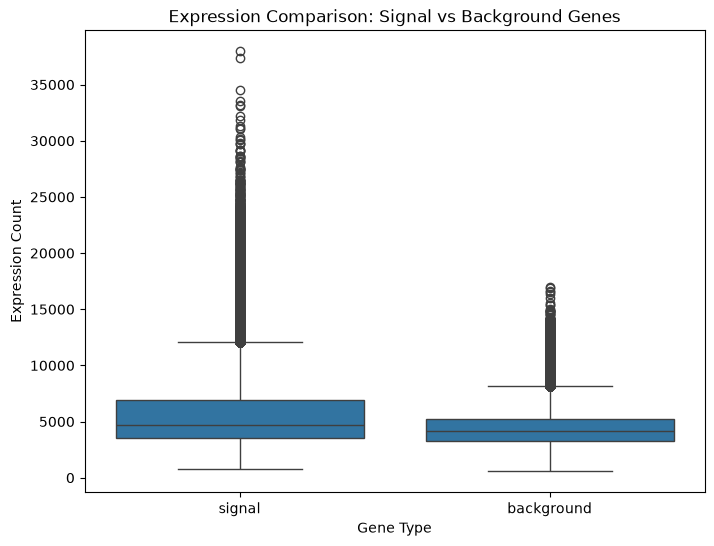

In [11]:
# Step 11: box plot for signal vs background gene expression

plot_df = counts_df.copy()

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x="gene_type", y="expression")
plt.title("Expression Comparison: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Expression Count")
plt.show()

Step 11a: PIT QQ plot — is the NB simulation correctly parameterized?

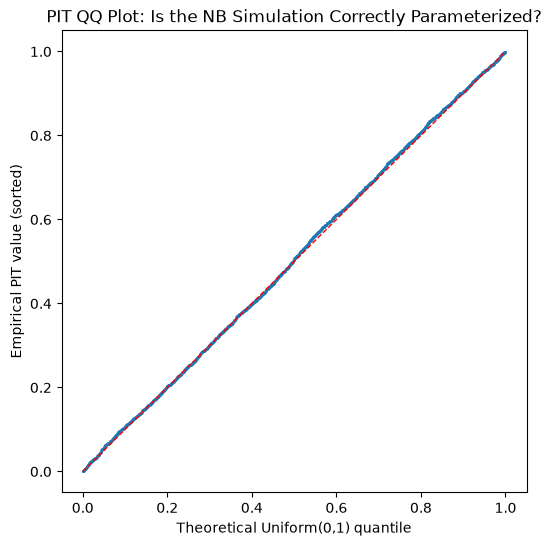

In [12]:
# Step 11a: validate the NB parameterization via a PIT QQ plot
#
# Each observation has its OWN Negative Binomial distribution (mu depends on
# that observation's size_factor and gamma_i), so a naive single-
# distribution QQ plot doesn't apply here. Instead, use the probability
# integral transform (PIT): for each observed count, compute
# u = NB_CDF(count; n, p) using THAT SAME observation's own (n, p). If the
# simulation is correctly parameterized, these u values should be
# (approximately) Uniform(0, 1) -- so a QQ plot of sorted u against Uniform
# quantiles should fall close to the y=x line.
#
# Caveat: NB is discrete, so PIT values have a known small "staircase" bias
# relative to a truly continuous Uniform(0,1) -- this is expected and not a
# sign of misparameterization; look for a large systematic bend, not
# perfect exactness.

from scipy.stats import nbinom

pit_sample = counts_df[counts_df["gene_type"] == "background"].merge(
    cells_df[["cell_id", "size_factor"]], on="cell_id"
).merge(patients_df[["patient_id", "gamma_i"]], on="patient_id").sample(
    n=3000, random_state=42
)

pit_mu = (pit_sample["size_factor"] * (mu_background + pit_sample["gamma_i"])).clip(lower=MU_FLOOR)
pit_var = pit_mu + (pit_mu ** 2) / dispersion
pit_p = pit_mu / pit_var
pit_n = pit_mu * pit_p / (1 - pit_p)

u = nbinom.cdf(pit_sample["expression"], pit_n, pit_p)
u_sorted = np.sort(u)
uniform_quantiles = np.linspace(0, 1, len(u_sorted))

plt.figure(figsize=(6, 6))
plt.plot(uniform_quantiles, u_sorted, ".", markersize=2, alpha=0.5)
plt.plot([0, 1], [0, 1], "r--", linewidth=1)
plt.xlabel("Theoretical Uniform(0,1) quantile")
plt.ylabel("Empirical PIT value (sorted)")
plt.title("PIT QQ Plot: Is the NB Simulation Correctly Parameterized?")
plt.show()

Step 11b: validate the induced module correlation

In [13]:
# Step 11b: check realized within-module correlation
#
# Raw counts are contaminated by a technical correlation floor: size_factor
# multiplies every gene's mean within a cell, so ALL genes look correlated
# with each other regardless of module structure. To see the correlation the
# copula actually added, normalize expression by size_factor first (CPM-style)
# before computing pairwise correlations. Restricting to Group1 cells also
# avoids the trivial correlation induced by the group mean difference itself.
#
# NOTE on the background/distractor numbers below: gamma_i (the patient
# random effect) is now added additively to every gene's mean, not just
# disease-module genes (Step 8). Since gamma_i is constant across all of a
# patient's cells, it survives the size_factor normalization above and
# induces a real, nonzero "floor" correlation among ALL genes -- including
# background. This is expected, not leakage: it's the honest consequence of
# treating gamma_i as a genuine patient-level effect. Read the numbers below
# as "distractor sits meaningfully above the shared floor (from the module
# copula); background sits at the floor" rather than "zero vs. correlated."
# The exact floor value depends on mu_background/sigma2/dispersion together
# (not just "independent genes -> ~0"), so don't hand-copy a fixed number
# anywhere permanent -- read it fresh from background_corr below.
#
# THIRD gotcha (subtype floor): for a DISEASE module specifically, pooling
# ALL Group1 cells is now wrong -- only the subtypes that activate that
# module have it boosted, so pooling boosted and unboosted patients together
# creates a large between-patient mean split (e.g. M1: ~boosted for S1/S3,
# baseline for S2). That split inflates the naive pooled correlation WAY
# above the copula's actual target, the same failure mode as the technical
# and patient-effect floors above, just one level up. Fix: measure a disease
# module's correlation only within cells from ONE subtype that activates it
# (every patient in that subtype has the SAME boost status for that module,
# so no between-patient mean-split confound remains -- same idea as
# restricting to Group1 in the first place). Distractor/background are never
# subtype-boosted, so pooling all of Group1 for them is still correct.

norm_counts_df = counts_df.merge(cells_df[["cell_id", "size_factor"]], on="cell_id")
norm_counts_df["norm_expression"] = norm_counts_df["expression"] / norm_counts_df["size_factor"]

g1_cells = cells_df.loc[cells_df["group"] == "Group1", "cell_id"]
norm_mat_g1 = norm_counts_df[norm_counts_df["cell_id"].isin(g1_cells)].pivot_table(
    index="gene_id", columns="cell_id", values="norm_expression"
)

def avg_offdiag_corr(gene_list, cell_ids=None):
    """Average off-diagonal pairwise correlation among `gene_list`. Restricts
    to `cell_ids` if given (a subset of norm_mat_g1's columns), else uses all
    of norm_mat_g1 (all Group1 cells)."""
    mat = norm_mat_g1[cell_ids] if cell_ids is not None else norm_mat_g1
    sub = mat.loc[gene_list]
    c = sub.T.corr().values
    mask = ~np.eye(len(gene_list), dtype=bool)
    return c[mask].mean()

def single_subtype_cells(module):
    """Cell ids for one subtype that activates `module` -- every patient in
    it shares the same (boosted) status for this module, so no between-
    patient mean-split confound. Falls back to None (all Group1) for
    modules no subtype activates (the distractor)."""
    activating_subtypes = [s for s in subtype_names if module in subtype_module_map[s]]
    if not activating_subtypes:
        return None
    subtype_patients = patients_df.loc[patients_df["subtype"] == activating_subtypes[0], "patient_id"]
    subtype_cell_ids = cells_df.loc[cells_df["patient_id"].isin(subtype_patients), "cell_id"]
    return norm_mat_g1.columns.intersection(subtype_cell_ids)

module_corr_results = {}
print("Avg pairwise correlation (normalized expression; disease modules measured")
print("within one activating subtype's cells, distractor/background across all Group1)")
print("-" * 78)
for module in module_names:
    kind = "disease" if module in disease_modules else "distractor"
    genes_in_module = module_gene_lists[module]
    corr_val = avg_offdiag_corr(genes_in_module, cell_ids=single_subtype_cells(module))
    module_corr_results[module] = corr_val
    print(f"{module} ({kind:10s}): {corr_val:.3f}")

bg_sample = list(np.random.choice(background_gene_ids, genes_per_module, replace=False))
background_corr = avg_offdiag_corr(bg_sample)
print(f"{'background':13s}: {background_corr:.3f}  <- shared patient-effect floor, not leakage (see note above)")

Avg pairwise correlation (normalized expression; disease modules measured
within one activating subtype's cells, distractor/background across all Group1)
------------------------------------------------------------------------------
M1 (disease   ): 0.569
M2 (disease   ): 0.628
M3 (disease   ): 0.595
M4 (distractor): 0.629
background   : 0.203  <- shared patient-effect floor, not leakage (see note above)


Step 11c: dataset overview

In [14]:
# Step 11c: dataset overview

overview = pd.DataFrame({
    "quantity": [
        "Patients (total)", "Patients per group (G1 / G2)", "Cells per patient", "Cells (total)",
        "Genes (total)", "Signal genes (in modules)", "Background genes",
        "Disease modules", "Distractor modules", "Genes per module",
        "Target within-module correlation", "Fold change (disease modules)",
        "NB dispersion", "Patient-effect variance (sigma2)"
    ],
    "value": [
        len(patients_df), f"{n_patients_group1} / {n_patients_group2}", cells_per_patient, len(cells_df),
        n_genes_total, n_signal_genes, n_genes_total - n_signal_genes,
        len(disease_modules), len(distractor_module_names), genes_per_module,
        within_module_correlation, fold_change,
        dispersion, sigma2
    ]
})
overview

,quantity,value
0,Patients (total),20
1,Patients per group (G1 / G2),10 / 10
2,Cells per patient,50
3,Cells (total),1000
4,Genes (total),1000
5,Signal genes (in modules),100
6,Background genes,900
7,Disease modules,3
8,Distractor modules,1
9,Genes per module,25


Step 11d: technical and patient-effect distributions (QC)

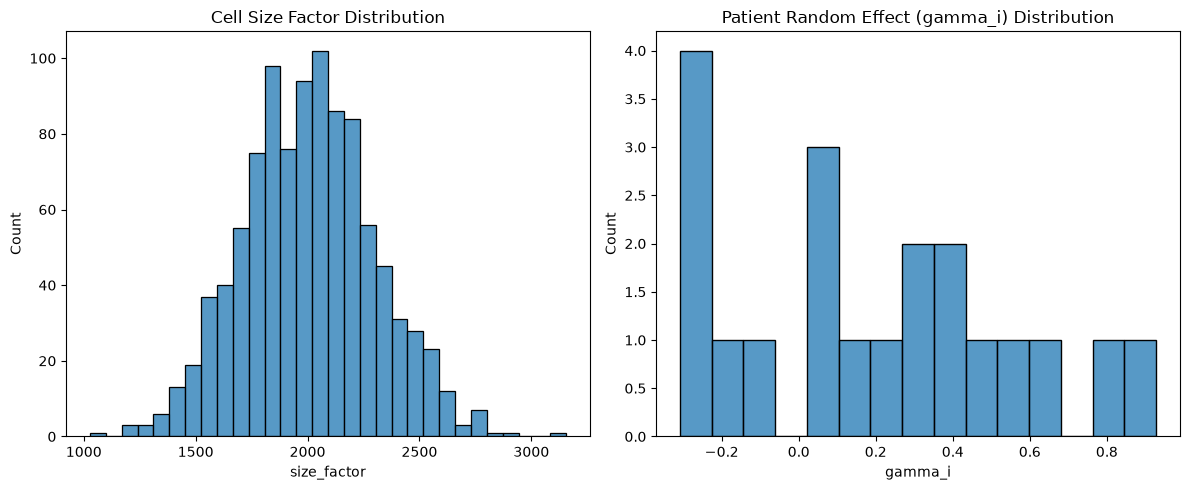

,mean,std,min,max
group,,,,
Group1,0.217930,0.301689,-0.289319,0.625811
Group2,0.170096,0.449775,-0.308214,0.928085


In [15]:
# Step 11d: technical and patient-effect distributions (QC)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(cells_df["size_factor"], bins=30, ax=axes[0])
axes[0].set_title("Cell Size Factor Distribution")
axes[0].set_xlabel("size_factor")

sns.histplot(patients_df["gamma_i"], bins=15, ax=axes[1])
axes[1].set_title("Patient Random Effect (gamma_i) Distribution")
axes[1].set_xlabel("gamma_i")

plt.tight_layout()
plt.show()

patients_df.groupby("group")["gamma_i"].agg(["mean", "std", "min", "max"])

Step 11e: expression distribution by gene type (log scale)

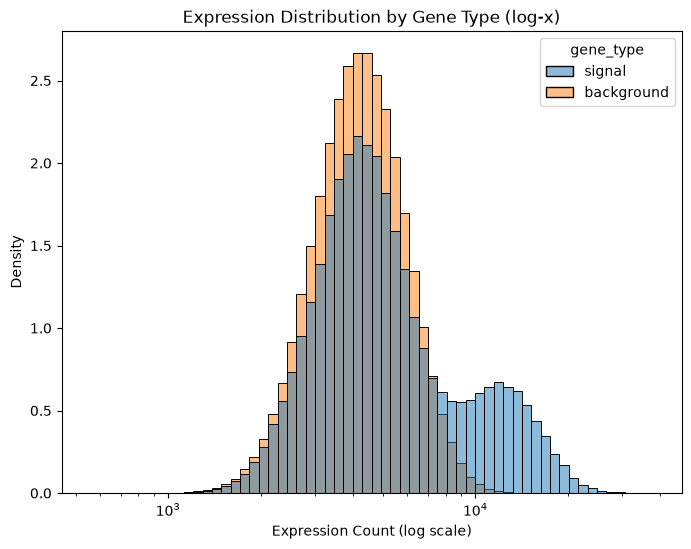

In [16]:
# Step 11e: expression distribution by gene type (log scale)

plt.figure(figsize=(8, 6))
sns.histplot(
    data=counts_df, x="expression", hue="gene_type",
    bins=60, log_scale=(True, False), stat="density", common_norm=False, alpha=0.5
)
plt.title("Expression Distribution by Gene Type (log-x)")
plt.xlabel("Expression Count (log scale)")
plt.show()

Step 11f: per-module expression by group (does the fold-change show up per module?)

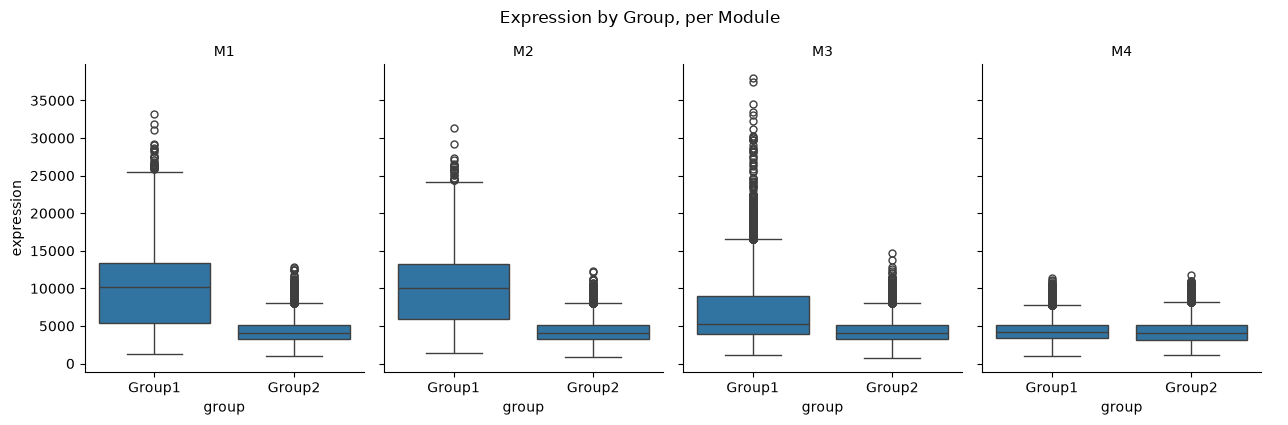

In [17]:
# Step 11f: per-module expression by group
#
# Disease modules (M1-M3) should show a visible shift between Group1 and
# Group2; the distractor module (M4) should not, even though it is just as
# internally correlated.

module_counts = counts_df[counts_df["module_id"] != "none"]

g = sns.catplot(
    data=module_counts, x="group", y="expression", col="module_id",
    kind="box", col_order=module_names, height=4, aspect=0.8
)
g.set_titles("{col_name}")
g.fig.suptitle("Expression by Group, per Module", y=1.05)
plt.show()

Step 11f-ii: per-module expression by subtype (does each subtype boost only its own modules?)

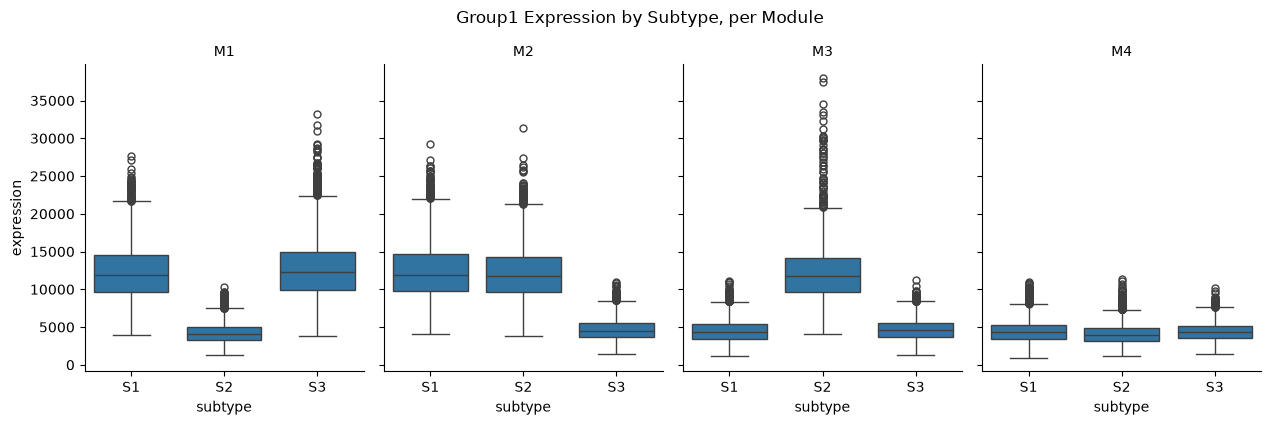

Subtype -> active (boosted) modules (should match the elevated boxes above):
  S1: ['M1', 'M2']
  S2: ['M2', 'M3']
  S3: ['M1']


In [18]:
# Step 11f-ii: per-module expression by subtype -- Group1 patients only
#
# Validates the subtype ground truth from Step 2/3/5: within Group1, a
# module should show elevated expression ONLY for subtypes that
# subtype_module_map says activate it. e.g. M1 should be elevated for S1
# and S3 but not S2; M3 should be elevated for S2 only. If every subtype
# looked the same on every module, the subtype-gating logic in Step 8
# would not be doing what it claims.

g1_counts = counts_df[
    (counts_df["group"] == "Group1") & (counts_df["module_id"] != "none")
].merge(patients_df[["patient_id", "subtype"]], on="patient_id")

g = sns.catplot(
    data=g1_counts, x="subtype", y="expression", col="module_id",
    kind="box", col_order=module_names, order=subtype_names, height=4, aspect=0.8
)
g.set_titles("{col_name}")
g.fig.suptitle("Group1 Expression by Subtype, per Module", y=1.05)
plt.show()

print("Subtype -> active (boosted) modules (should match the elevated boxes above):")
for subtype in subtype_names:
    print(f"  {subtype}: {sorted(subtype_module_map[subtype])}")

Step 11g: correlation heatmaps — disease module vs distractor vs background

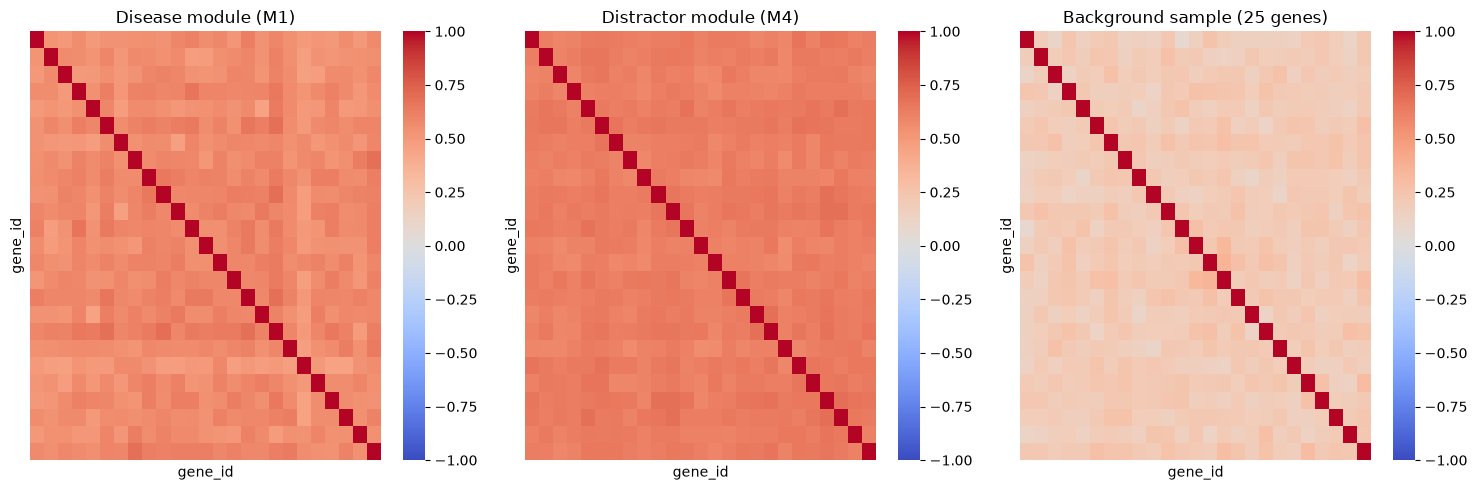

In [19]:
# Step 11g: correlation heatmaps -- disease module vs distractor vs background
#
# Visual counterpart to the numbers above: a disease module and the
# distractor module should both show a solid block of correlation, while a
# random sample of background genes should look like noise. Uses the full
# valid correlation range (-1 to 1) with a diverging colormap centered at 0,
# since correlation_noise (Step 2) can push individual gene pairs negative.
#
# The disease-module panel is restricted to one activating subtype's cells
# (see single_subtype_cells in Step 11b) -- pooling all of Group1 here would
# mix boosted and unboosted patients for that module and visually inflate
# the block well past the copula's actual target, the "subtype floor" issue
# documented in Step 11b.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

disease_module_cells = single_subtype_cells(disease_modules[0])
heatmap_specs = [
    (module_gene_lists[disease_modules[0]], disease_module_cells, f"Disease module ({disease_modules[0]})"),
    (module_gene_lists[distractor_module_names[0]], None, f"Distractor module ({distractor_module_names[0]})"),
    (bg_sample, None, "Background sample (25 genes)")
]

for ax, (gene_list, cell_ids, title) in zip(axes, heatmap_specs):
    mat = norm_mat_g1[cell_ids] if cell_ids is not None else norm_mat_g1
    corr = mat.loc[gene_list].T.corr()
    sns.heatmap(corr, ax=ax, vmin=-1, vmax=1, cmap="coolwarm", center=0, cbar=True, xticklabels=False, yticklabels=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

Step 11g-ii: zoomed heatmap — module 1 genes mixed with background genes

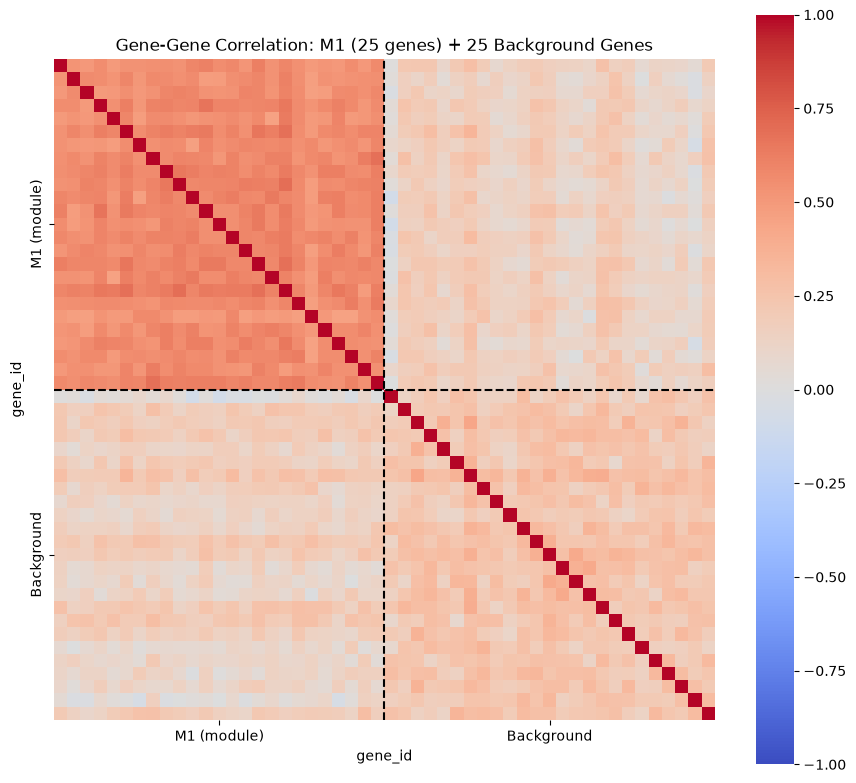

In [20]:
# Step 11g-ii: zoomed correlation heatmap -- module 1 mixed with background genes
#
# 50 genes total: the first 25 belong to disease module M1, the last 25 are
# a random background sample (the same bg_sample used above). Unlike the
# side-by-side panels above, this puts both gene sets in ONE matrix so the
# M1 block should visibly stand out against the uncorrelated background
# genes surrounding it. Uses the full valid correlation range (-1 to 1) with
# a diverging colormap centered at 0.
#
# Both gene sets are measured within the SAME cell subset -- one subtype
# that activates M1 (see Step 11b's "subtype floor" note) -- rather than all
# of Group1, so M1's block reflects the copula's actual target correlation
# instead of an inflated, subtype-mixed number. Background still shows its
# usual patient-effect floor within this smaller cell subset.

module1_genes = module_gene_lists[disease_modules[0]]
mixed_gene_list = module1_genes + bg_sample
module1_cells = single_subtype_cells(disease_modules[0])
mixed_corr = norm_mat_g1[module1_cells].loc[mixed_gene_list].T.corr()

plt.figure(figsize=(9, 8))
ax = sns.heatmap(
    mixed_corr, vmin=-1, vmax=1, cmap="coolwarm", center=0, cbar=True,
    xticklabels=False, yticklabels=False, square=True
)
ax.axvline(len(module1_genes), color="black", linestyle="--", linewidth=1.5)
ax.axhline(len(module1_genes), color="black", linestyle="--", linewidth=1.5)
ax.set_xticks([len(module1_genes) / 2, len(module1_genes) + len(bg_sample) / 2])
ax.set_xticklabels([f"{disease_modules[0]} (module)", "Background"])
ax.set_yticks([len(module1_genes) / 2, len(module1_genes) + len(bg_sample) / 2])
ax.set_yticklabels([f"{disease_modules[0]} (module)", "Background"], rotation=90, va="center")
plt.title(f"Gene-Gene Correlation: {disease_modules[0]} (25 genes) + 25 Background Genes")
plt.tight_layout()
plt.show()

Step 11h: PCA of cells using only module genes

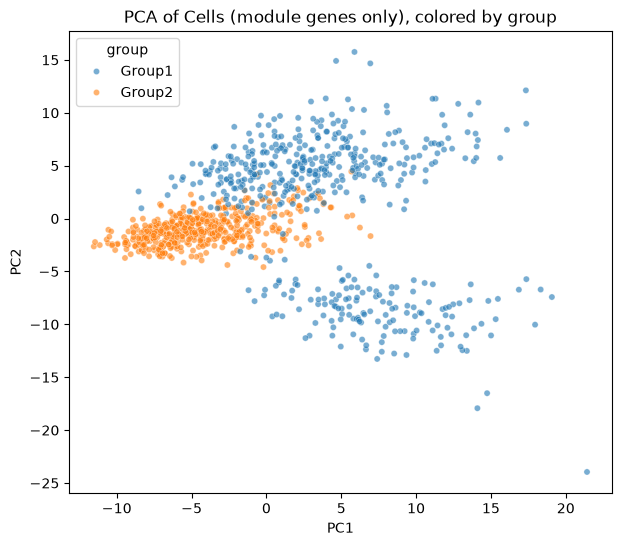

In [21]:
# Step 11h: PCA of cells using only module genes (disease + distractor)
#
# If the disease modules carry real group signal, cells should separate by
# group along the leading principal components even before any classifier
# is trained on them.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

module_gene_ids = [g for genes in module_gene_lists.values() for g in genes]
signal_matrix = counts_df[counts_df["gene_id"].isin(module_gene_ids)].pivot_table(
    index="cell_id", columns="gene_id", values="expression", fill_value=0
)

cell_group_lookup = cells_df.set_index("cell_id")["group"].loc[signal_matrix.index]

scaled = StandardScaler().fit_transform(signal_matrix.values)
pcs = PCA(n_components=2, random_state=42).fit_transform(scaled)

pca_df = pd.DataFrame({"PC1": pcs[:, 0], "PC2": pcs[:, 1], "group": cell_group_lookup.values})

plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="group", alpha=0.6, s=20)
plt.title("PCA of Cells (module genes only), colored by group")
plt.show()

**Step 12: baseline feature selection.** Trains an L1-penalized (LASSO) logistic regression to test whether a standard, group-and-subtype-unaware method recovers the true signal genes and modules. This is the baseline the eventual group-aware gating framework (methodology step 4) needs to beat.

# L1 Gating Test

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import GroupShuffleSplit

# scikit-learn >=1.8 emits a FutureWarning about the penalty= param being
# deprecated in favor of l1_ratio=; harmless here (we're pinned to
# penalty="l1"/solver="saga"), suppressed so it doesn't clutter the report.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [23]:
# Build cell-level matrix
X_df = counts_df.pivot_table(
    index="cell_id",
    columns="gene_id",
    values="expression",
    aggfunc="sum",
    fill_value=0
)

cell_labels = cells_df[["cell_id", "group"]].drop_duplicates().set_index("cell_id").loc[X_df.index]
y = (cell_labels["group"] == "Group2").astype(int).values

gene_types = genes_df.set_index("gene_id").loc[X_df.columns, "gene_type"]

In [24]:
# Split and train L1 model
# X_train, X_test, y_train, y_test = train_test_split(
#     X_df.values, y, test_size=0.2, random_state=42, stratify=y
# )

groups_arr = cell_labels.index.map(lambda c: c.split("_")[0]).values  # patient_id per cell
gss = GroupShuffleSplit(n_splits=1, test_size=L1_TEST_SIZE, random_state=42)
train_idx, test_idx = next(gss.split(X_df.values, y, groups=groups_arr))

X_train, X_test = X_df.values[train_idx], X_df.values[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

#cross validation for lambda tuning, define loss function
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=L1_C,  # C=1/Lambda. Low C = strong regularization, high C = weak regularization.
    # Retuned via sweep to land test accuracy in the ~75-85% target zone --
    # subtype-gated module boosting (Step 8) dilutes the group-level signal
    # since only a fraction of Group1 patients boost any given disease
    # module, so C needed to move up (weaker regularization) relative to the
    # pre-subtype design. See CLAUDE.md parameter tuning notes.
    max_iter=L1_MAX_ITER,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Convergence check: saga stops at max_iter whether or not it actually
# converged, so a silent non-convergence would otherwise look identical to
# a converged fit -- surface it instead of assuming.
if model.n_iter_[0] >= L1_MAX_ITER:
    print(f"WARNING: solver used the full {L1_MAX_ITER} iterations -- may not have converged. "
          f"Consider raising L1_MAX_ITER (Step 2).")
else:
    print(f"Solver converged in {model.n_iter_[0]} / {L1_MAX_ITER} iterations")

train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Solver converged in 794 / 5000 iterations
Train accuracy: 0.81125
Test accuracy: 0.8


In [25]:
# Extract gene scores
coef = model.coef_[0]

feature_scores = pd.DataFrame({
    "gene_id": X_df.columns,
    "gene_type": gene_types.values,
    "coef": coef,
    "abs_coef": np.abs(coef)
})

feature_scores.head()

,gene_id,gene_type,coef,abs_coef
0,G1,signal,-0.250445,0.250445
1,G10,signal,0.000000,0.000000
2,G100,signal,0.000000,0.000000
3,G1000,background,0.000000,0.000000
4,G101,background,0.000000,0.000000


Step 12b: does L1 recover whole modules, or just 1-2 representative genes?

Step 12b-ii: recovery scatter — true effect size vs. what L1 actually selected

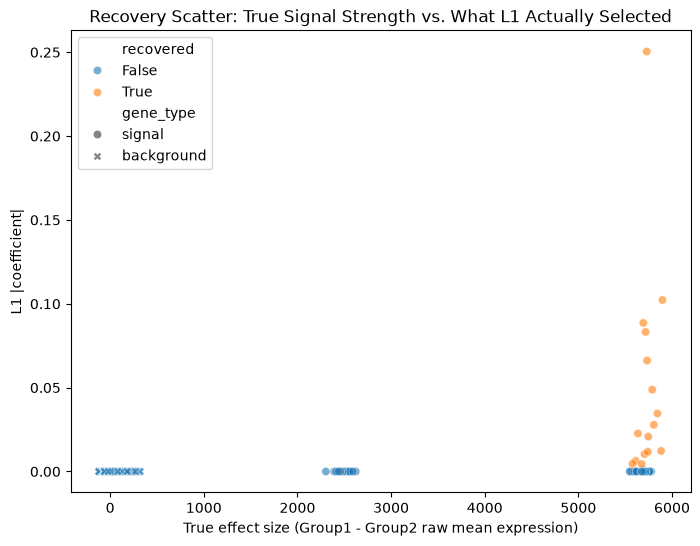

In [26]:
# Step 12b-ii: recovery scatter -- true effect size vs L1 coefficient
#
# For every gene, plot its TRUE group-mean difference (raw Group1 - Group2
# expression) against the L1 |coefficient| it actually received, colored by
# whether L1 gave it a nonzero coefficient. A flat recovery-rate number
# hides cases like "a gene with a large true effect got zeroed out anyway"
# -- this picture catches that.

from scipy.stats import nbinom  # re-imported locally for cell self-containedness

gene_group_means = counts_df.groupby(["gene_id", "group"])["expression"].mean().unstack()
effect_size = (gene_group_means["Group1"] - gene_group_means["Group2"]).rename("effect_size")

scatter_df = feature_scores.merge(effect_size, on="gene_id")
scatter_df["recovered"] = scatter_df["coef"] != 0

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=scatter_df, x="effect_size", y="abs_coef",
    hue="recovered", style="gene_type", alpha=0.6
)
plt.xlabel("True effect size (Group1 - Group2 raw mean expression)")
plt.ylabel("L1 |coefficient|")
plt.title("Recovery Scatter: True Signal Strength vs. What L1 Actually Selected")
plt.show()

module_id       kind  genes_in_module  genes_recovered  recovery_rate
       M1    disease               25                9           0.36
       M2    disease               25                8           0.32
       M3    disease               25                0           0.00
       M4 distractor               25                0           0.00

Sanity check passed: disease modules recovered more than the distractor (0.227 vs 0.000)


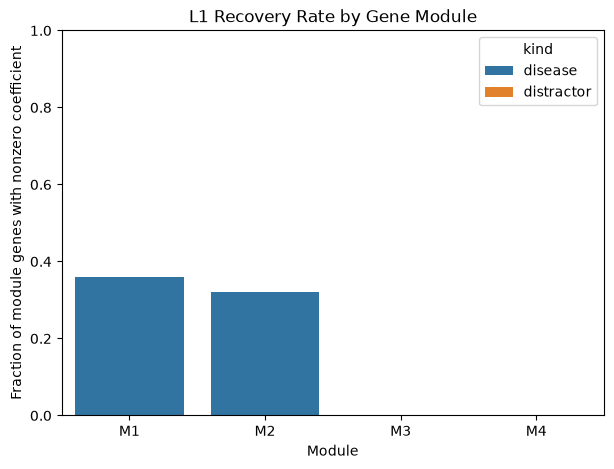

In [27]:
# Step 12b: per-module recovery rate
#
# Recovery rate = (# genes in a module with a nonzero L1 coefficient) / (module size).
# This is the core empirical test: if L1 treats genes independently, it should
# grab only a handful of "representative" genes per disease module even though
# the whole module carries signal. The distractor module is a negative control:
# it's just as internally correlated as a disease module, but should get ~0
# recovery since it carries no group-discriminating signal.
#
# Why recovery is expected to be well under 100% (not a bug): L1 doesn't
# reward using MORE correlated genes -- among a block of ~equally
# informative, highly correlated predictors, L1's penalty is indifferent to
# which one it keeps, so it arbitrarily zeroes out most of them once one or
# two are "good enough". Lower recovery for a specific module (e.g. one
# activated by a rarer subtype, so fewer patients carry its signal) reflects
# a weaker/sparser true signal in the training data, not an error.

feature_scores = feature_scores.merge(
    genes_df[["gene_id", "module_id", "is_disease_module"]], on="gene_id"
)

recovery_rows = []
for module in module_names:
    sub = feature_scores[feature_scores["module_id"] == module]
    n_nonzero = (sub["coef"] != 0).sum()
    recovery_rows.append({
        "module_id": module,
        "kind": "disease" if module in disease_modules else "distractor",
        "genes_in_module": len(sub),
        "genes_recovered": n_nonzero,
        "recovery_rate": n_nonzero / len(sub)
    })

recovery_df = pd.DataFrame(recovery_rows)
print(recovery_df.to_string(index=False))

disease_avg_recovery = recovery_df.loc[recovery_df["kind"] == "disease", "recovery_rate"].mean()
distractor_avg_recovery = recovery_df.loc[recovery_df["kind"] == "distractor", "recovery_rate"].mean()
assert disease_avg_recovery > distractor_avg_recovery, (
    f"expected disease modules to be recovered more than the distractor module "
    f"({disease_avg_recovery:.3f} vs {distractor_avg_recovery:.3f}) -- if this fails, "
    f"L1 is no longer distinguishing real signal from mere correlation, which would "
    f"undermine the whole comparison."
)
print(f"\nSanity check passed: disease modules recovered more than the distractor "
      f"({disease_avg_recovery:.3f} vs {distractor_avg_recovery:.3f})")

plt.figure(figsize=(7, 5))
sns.barplot(data=recovery_df, x="module_id", y="recovery_rate", hue="kind")
plt.title("L1 Recovery Rate by Gene Module")
plt.xlabel("Module")
plt.ylabel("Fraction of module genes with nonzero coefficient")
plt.ylim(0, 1)
plt.show()

Step 12c: L1 coefficient magnitude by module

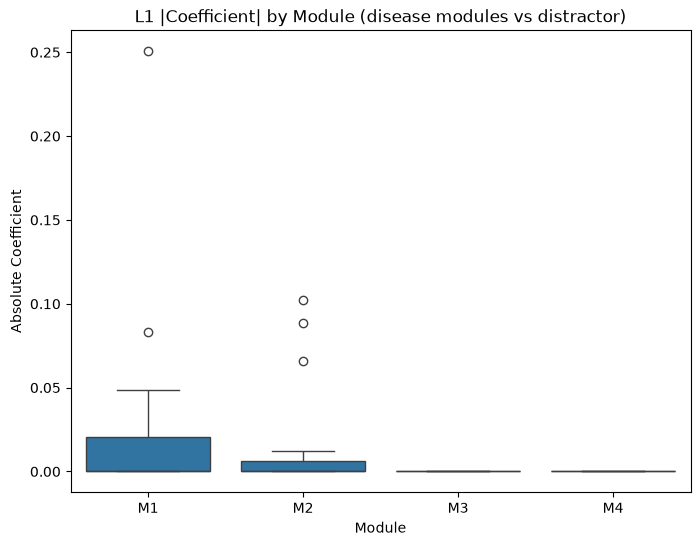

In [28]:
# Step 12c: L1 coefficient magnitude by module

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=feature_scores[feature_scores["module_id"] != "none"],
    x="module_id", y="abs_coef", order=module_names
)
plt.title("L1 |Coefficient| by Module (disease modules vs distractor)")
plt.xlabel("Module")
plt.ylabel("Absolute Coefficient")
plt.show()

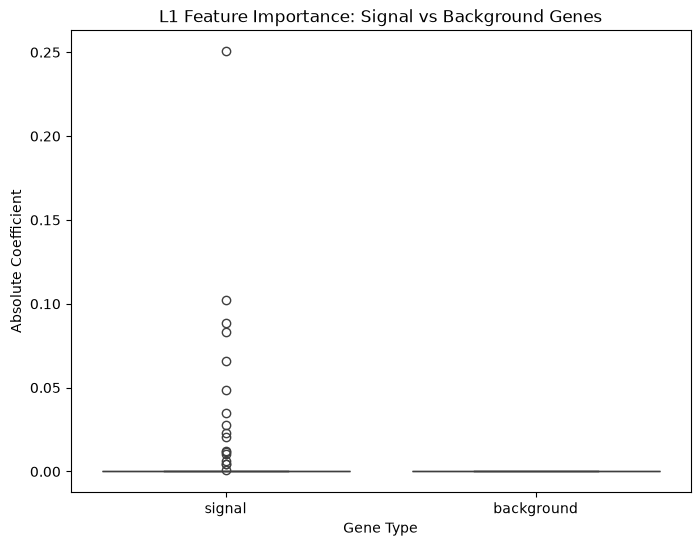

In [29]:
# Compare signal vs. background
plt.figure(figsize=(8, 6))
sns.boxplot(data=feature_scores, x="gene_type", y="abs_coef")
plt.title("L1 Feature Importance: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Absolute Coefficient")
plt.show()

In [30]:
# Long format (one row per cell-gene pair) — good for records/reproducibility
#counts_df.to_csv("counts_long.csv", index=False)

# Wide format (genes as rows, cells as columns) — good for feeding into a model
#expression_matrix.to_csv("expression_matrix.csv")

# Gene answer key (which genes are signal vs background)
#genes_df.to_csv("genes_labels.csv", index=False)

# Patient metadata (group, gamma_i)
#patients_df.to_csv("patients.csv", index=False)

Step 13: summary report

In [31]:
# Step 13: summary report

summary_report = pd.DataFrame({
    "metric": [
        "Test accuracy", "Train accuracy", "L1 regularization C",
        "Total nonzero coefficients", "Background genes w/ nonzero coef",
        "Disease module avg recovery rate", "Distractor module recovery rate",
        "Target within-module correlation",
        "Realized correlation - disease modules (avg)",
        "Realized correlation - distractor module",
        "Realized correlation - background genes"
    ],
    "value": [
        round(test_acc, 4),
        round(train_acc, 4),
        model.C,
        int((feature_scores["coef"] != 0).sum()),
        int((feature_scores.loc[feature_scores["gene_type"] == "background", "coef"] != 0).sum()),
        round(recovery_df.loc[recovery_df["kind"] == "disease", "recovery_rate"].mean(), 4),
        round(recovery_df.loc[recovery_df["kind"] == "distractor", "recovery_rate"].mean(), 4),
        within_module_correlation,
        round(np.mean([module_corr_results[m] for m in disease_modules]), 4),
        round(module_corr_results[distractor_module_names[0]], 4),
        round(background_corr, 4)
    ]
})
summary_report

,metric,value
0,Test accuracy,0.8000
1,Train accuracy,0.8113
2,L1 regularization C,0.0068
3,Total nonzero coefficients,17.0000
4,Background genes w/ nonzero coef,0.0000
5,Disease module avg recovery rate,0.2267
6,Distractor module recovery rate,0.0000
7,Target within-module correlation,0.6000
8,Realized correlation - disease modules (avg),0.5974
9,Realized correlation - distractor module,0.6293
